# SGD

- BGD (Batch Gradient Descent): using all samples
- SGD (Stochastic Gradient Discent): using 1 sample
- MBGD (Mini-batch Gradient Descent): using parts of samples

$w=w-\eta\times g$

## pros:

easy to be implemented

## cons:

- senstivity to learning rate
- converge to local optimal solution
- cannot further optimize model near global optimal solution (gradient vanishment)


# example: optimize f(x)=x^2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'f(x)')

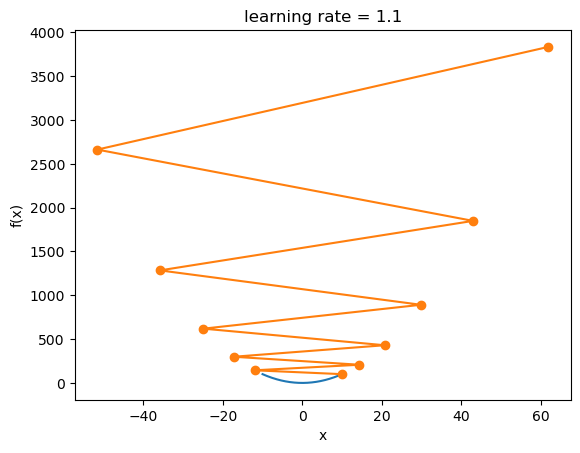

In [10]:
x = 10
lr = 1.1
results = [x]

for i in range(10):
    x -= lr * 2 * x
    results.append(x)

f_line = np.arange(-10, 10, 0.1)
plt.plot(f_line, [x**2 for x in f_line])
plt.plot(results, [x**2 for x in results], '-o')
plt.title('learning rate = {}'.format(lr))
plt.xlabel('x')
plt.ylabel('f(x)')

# two dim example

$f(x) = x_1^2 + 2x_2^2$

$\nabla(f(x)) = [2x_1, 4x_2]^T$

Text(0, 0.5, 'x2')

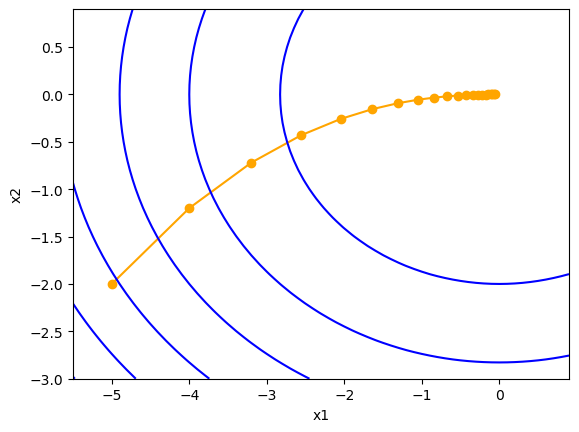

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def loss_func(x1, x2):
    return x1**2 + 2*x2**2

x1, x2 = -5, -2
eta = 0.1
num_epochs = 20
results = [(x1, x2)]

for epoch in range(num_epochs):
    gd1, gd2 = 2*x1, 4*x2

    x1 -= eta * gd1
    x2 -= eta * gd2

    results.append((x1,x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

# Momentum

Idea: introduces a variable $v$ that plays the role of velocity

$v(t)\gets \alpha v(t-1) - \eta \times g$

- $\alpha$: a hyperparameter determines how quickly the contributions of previous gradients exponentially decay.

- Gradient: increase/decrease the previous velocity

- Updating rule: $w \gets w - \eta \times v$

## pros:

- accelerate convergence on the correct direction
- jump out of local optima


# Example

$f(x) = 0.1 x_1^2 + 2x_2^2$

$x_1=-5$

$x_2=-2$

$\eta=0.4$

Expection: Since the coefficients of $x_1$ and $x_2$ are 0.1 and 2, using the same learning rate, $x_2$ is optimized faster than $x_1$

Text(0, 0.5, 'x2')

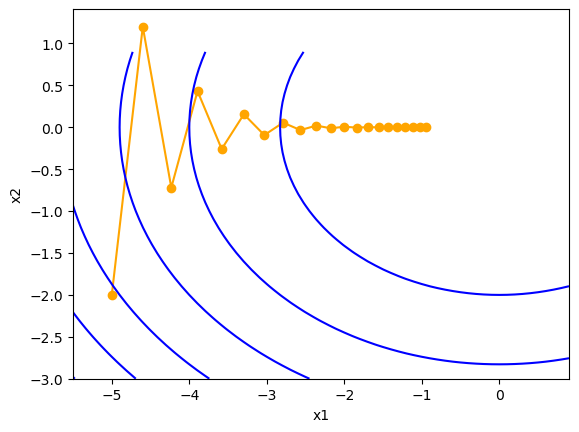

In [17]:
def loss_function(x1, x2):
    return 0.1 * x1**2 + 2 * x2**2

x1, x2 = -5, -2
eta = 0.4
num_epochs = 20
results = [(x1, x2)]

for epoch in range(num_epochs):
    gd1, gd2 = 0.2*x1, 4*x2

    x1 -= eta * gd1
    x2 -= eta * gd2

    results.append((x1,x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

Text(0, 0.5, 'x2')

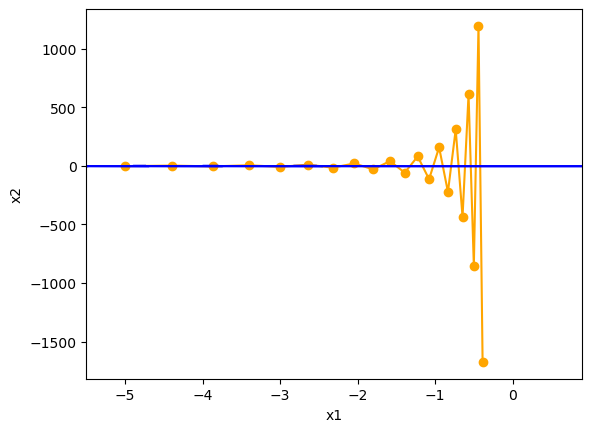

In [18]:
def loss_function(x1, x2):
    return 0.1 * x1**2 + 2 * x2**2

x1, x2 = -5, -2
eta = 0.6
num_epochs = 20
results = [(x1, x2)]

for epoch in range(num_epochs):
    gd1, gd2 = 0.2*x1, 4*x2

    x1 -= eta * gd1
    x2 -= eta * gd2

    results.append((x1,x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

Text(0, 0.5, 'x2')

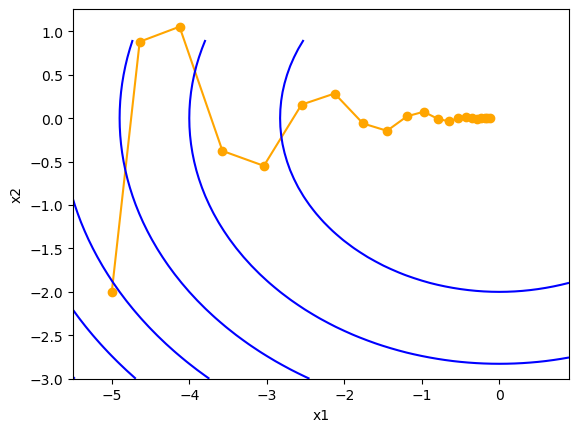

In [24]:
# Momentum

x1, x2 = -5, -2
v1, v2 = 0, 0
eta, alpha = 0.6, 0.5
num_epochs = 20
results = [(x1, x2)]

for epoch in range(num_epochs):
    v1 = alpha * v1 + eta * 0.2 * x1
    v2 = alpha * v2 + eta * 4 * x2

    x1 -= eta*v1
    x2 -= eta*v2

    results.append((x1, x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

Text(0, 0.5, 'x2')

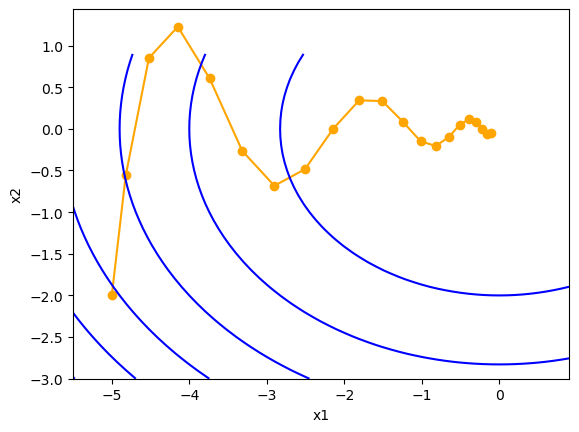

In [23]:
# momentum, another solution

x1, x2 = -5, -2
v1, v2 = 0, 0
eta, alpha = 0.6, 0.7
num_epochs = 20
results = [(x1, x2)]

for epoch in range(num_epochs):
    v1 = alpha * v1 + (1-alpha) * 0.2 * x1
    v2 = alpha * v2 + (1-alpha) * 4 * x2

    x1 -= eta*v1
    x2 -= eta*v2

    results.append((x1, x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

# Adaptive learning rate (AdaGrad)

Idea: set individual learning rate to different model weights. Adapts the learning rates of all model parameters by scaling them inversely proportional to the square root of the sum of all of their historical squared values


- accumulated gradient: $r \gets r + g^2$

- weight update: $w \gets w - \eta/\sqrt{r+\delta} \times g$


Text(0, 0.5, 'x2')

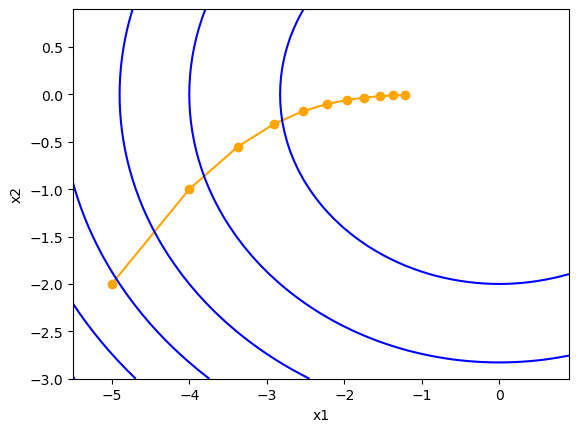

In [34]:
def loss_function(x1, x2):
    return 0.1 * x1**2 + 2 * x2**2

x1, x2 = -5, -2
r1, r2 = 0., 0.
delta = 1e-10
eta = 1
num_epochs = 10
results = [(x1, x2)]

for epoch in range(num_epochs):
    gd1, gd2 = 0.2*x1, 4*x2
    r1 += gd1**2
    r2 += gd2**2

    x1 -= eta * gd1 / np.sqrt(r1+delta)
    x2 -= eta * gd2 / np.sqrt(r2+delta)

    results.append((x1,x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

# RMSProp

Idea:

- accumulated gradient: $r \gets \lambda r + (1-\lambda) g^2$

- weight update: $w \gets w - \eta/\sqrt{r+\delta} \times g$

Text(0, 0.5, 'x2')

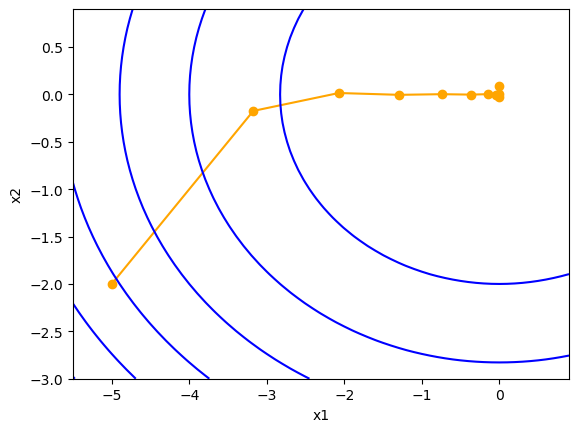

In [36]:
def loss_function(x1, x2):
    return 0.1 * x1**2 + 2 * x2**2

x1, x2 = -5, -2
r1, r2 = 0., 0.
delta = 1e-10
alpha = 0.7
eta = 1
num_epochs = 10
results = [(x1, x2)]

for epoch in range(num_epochs):
    gd1, gd2 = 0.2*x1, 4*x2
    r1 = alpha * r1 + (1-alpha) * gd1**2
    r2 = alpha * r2 + (1-alpha) * gd2**2

    x1 -= eta * gd1 / np.sqrt(r1+delta)
    x2 -= eta * gd2 / np.sqrt(r2+delta)

    results.append((x1,x2))

plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')

# Adam

Idea:

- gradient: add momentum. $v \gets \alpha v + (1-\alpha) g$

- Similar to RMSProp, update cumlative learning rate $r \gets \lambda r + (1-\lambda)g^2$

- Adjust v and r: 
- $\hat{v} = \frac{v}{1-\alpha^t}$
- $\hat{r} = \frac{r}{1-\lambda^t}$

- Update weights: $w \gets w - \frac{\eta}{\sqrt{\hat{r}+\delta}} * \hat{v}$

Text(0, 0.5, 'x2')

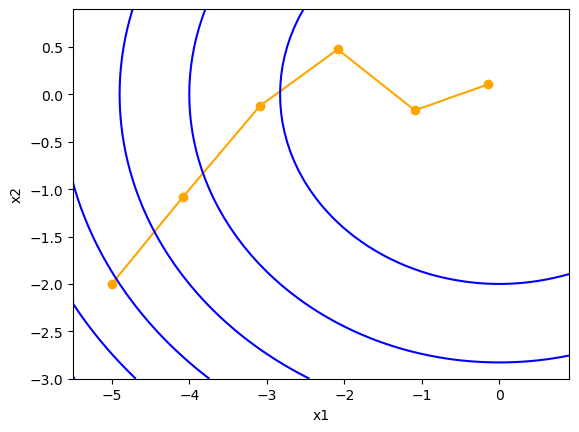

In [40]:
def loss_function(x1, x2):
    return 0.1 * x1**2 + 2 * x2**2

x1, x2 = -5, -2
r1, r2 = 0., 0.
v1, v2 = 0., 0.
delta = 1e-10
alpha = 0.2
eta = 1 # learning rate
t = 2

num_epochs = 5
results = [(x1, x2)]

for epoch in range(num_epochs):
    gd1, gd2 = 0.2*x1, 4*x2
    v1 = alpha*v1 + (1-alpha) * gd1
    v2 = alpha*v2 + (1-alpha) * gd2

    r1 = alpha * r1 + (1-alpha) * gd1**2
    r2 = alpha * r2 + (1-alpha) * gd2**2

    r1_hat, r2_hat = r1 / (1-alpha**t), r2 / (1-alpha**t)
    v1_hat, v2_hat = v1 / (1-alpha**t), v2 / (1-alpha**t)

    x1 -= eta * v1_hat / np.sqrt(r1_hat+delta)
    x2 -= eta * v2_hat / np.sqrt(r2_hat+delta)

    results.append((x1,x2))


plt.plot(*zip(*results), '-o', color='orange')
x1, x2 = np.meshgrid(np.arange(-5.5, 1.0, 0.1), np.arange(-3.0, 1.0, 0.1))
plt.contour(x1, x2, loss_func(x1, x2), colors='blue')
plt.xlabel('x1')
plt.ylabel('x2')